In [5]:
import pandas as pd
import pingouin as pg

df = pd.read_csv('Q2-data.csv')

print(df.head())

          S         C         A         P         D         Y
0  0.304717 -0.257952  0.480994  0.893223 -1.814366 -1.929140
1 -1.039984 -0.299486 -0.140861 -0.334011  0.608024 -0.119146
2  0.750451 -0.696660 -0.721819  0.589327 -0.390804 -0.107619
3  0.940565  0.428483  0.655267  1.800798 -1.853337 -1.580398
4 -1.951035  0.234646 -1.121882 -1.061530 -1.876908 -2.272004


In [8]:
print(df.describe())

                 S            C            A            P            D  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean     -0.019877    -0.000623    -0.028612     0.030801    -0.065449   
std       0.999454     1.013179     1.401464     1.787609     3.208492   
min      -3.648413    -4.389115    -4.970390    -5.737247   -12.016746   
25%      -0.691954    -0.661649    -1.000007    -1.146843    -2.206267   
50%      -0.004161    -0.020056    -0.061561     0.050469    -0.101172   
75%       0.631247     0.672299     0.897530     1.226820     2.112571   
max       3.454046     4.025824     5.711894     7.433183    11.972129   

                 Y  
count  5000.000000  
mean     -0.066099  
std       4.225908  
min     -15.660371  
25%      -2.921414  
50%      -0.111595  
75%       2.794084  
max      19.625290  


## Question 2b

In [15]:
# (i) Test A et C | {S, Y}
t1 = pg.partial_corr(data=df, x='A', y='C', covar=['S', 'Y'])
print("--- Résultat Test (i) ---")
print(t1) 

# (ii) Test Y et A | {D, P}
t2 = pg.partial_corr(data=df, x='Y', y='A', covar=['D', 'P'])
print("\n--- Résultat Test (ii) ---")
print(t2)

# (iii) Test D et S | {A, P, C}
t3 = pg.partial_corr(data=df, x='D', y='S', covar=['A', 'P', 'C'])
print("\n--- Résultat Test (iii) ---")
print(t3)

# Covariance directe
print("\n--- Covariance A, Y ---")
print(df['A'].cov(df['Y']))

--- Résultat Test (i) ---
            n         r         CI95          p_val
pearson  5000  0.474869  [0.45, 0.5]  1.414366e-279

--- Résultat Test (ii) ---
            n         r           CI95     p_val
pearson  5000 -0.006363  [-0.03, 0.02]  0.652912

--- Résultat Test (iii) ---
            n         r          CI95          p_val
pearson  5000  0.442062  [0.42, 0.46]  3.698923e-238

--- Covariance A, Y ---
3.417311996650286


### Conclusion Question 2b

* **(i) $A \perp C \mid \{S, Y\}$ : FALSE.** Fixer le profit ($Y$) crée une dépendance entre ses causes.
* **(ii) $Y \perp A \mid \{D, P\}$ : TRUE.** La demande ($D$) et le prix ($P$) bloquent l'influence de la pub sur le profit.
* **(iii) $D \perp S \mid \{A, P, C\}$ : FALSE.** La saison ($S$) influence directement la demande ($D$).

**Covariance (3.41) :** Elle est positive mais **ne prouve pas** la causalité. C'est une corrélation "météo" : la saison ($S$) fait monter la pub **et** le profit en même temps (confondeur).

array([[<Axes: title={'center': 'Y'}>, <Axes: title={'center': 'A'}>,
        <Axes: title={'center': 'S'}>]], dtype=object)

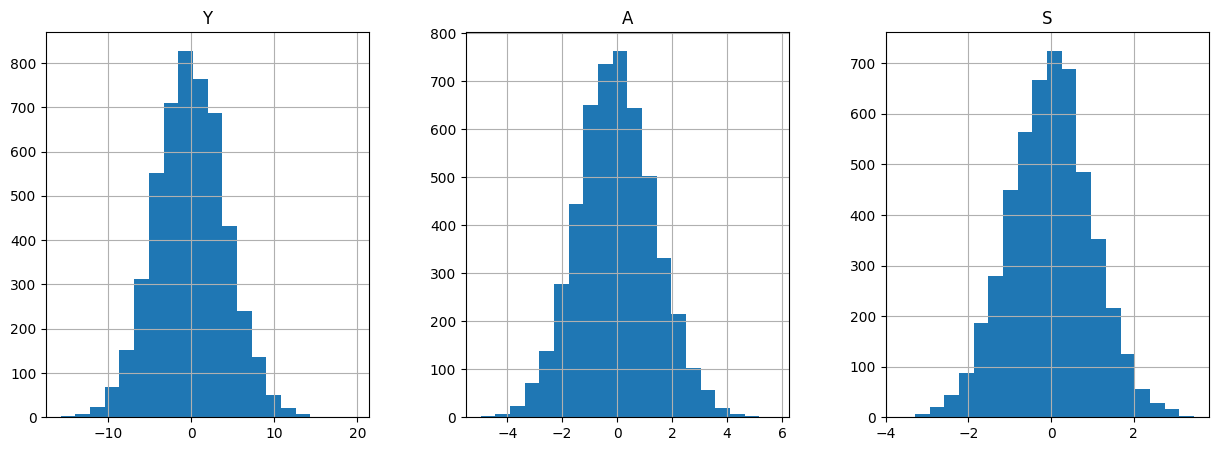

In [16]:
# Histograms for Y, A, and S
df[['Y', 'A', 'S']].hist(bins=20, figsize=(15, 5), layout=(1, 3))

Normality: All three variables ($Y, A, S$) follow a Normal distribution (the "bell curve" shape).

Mean 0: They are centered around $0$, confirming the data is standardized.

Interpretation: This distribution validates using linear regression and Pearson correlation for the rest of the homework.

In [17]:
import statsmodels.api as sm

# Effect of A on Y (controlling for S)
X1 = df[['A', 'S']]
X1 = sm.add_constant(X1)
model1 = sm.OLS(df['Y'], X1).fit()
print("ACE of A on Y (Coefficient of A):")
print(model1.params['A'])

ACE of A on Y (Coefficient of A):
1.5584052770541212


In [18]:
# Effect of D on Y (controlling for P)
X2 = df[['D', 'P']]
X2 = sm.add_constant(X2)
model2 = sm.OLS(df['Y'], X2).fit()
print("\nACE of D on Y (Coefficient of D):")
print(model2.params['D'])


ACE of D on Y (Coefficient of D):
1.5070580353497123


Even though the numbers are similar, if we look back at the answers for 2(c):

Ads ($A$) have a high ACE, but the effect is indirect (it might fail if the price is wrong).

Demand ($D$) has a similar ACE, but the effect is direct and more reliable.

In [23]:
# 1. Regression D ~ A + P + S (Impact of Ads on Demand)
X_D = sm.add_constant(df[['A', 'P', 'S']])
m_D = sm.OLS(df['D'], X_D).fit()
beta_AD = m_D.params['A']

# 2. Regression Y ~ D + P (Impact of Demand on Profit)
X_Y = sm.add_constant(df[['D', 'P']])
m_Y = sm.OLS(df['Y'], X_Y).fit()
beta_DY = m_Y.params['D']

# Indirect effect calculation
indirect = beta_AD * beta_DY

print("Coeff A->D:", beta_AD)
print("Coeff D->Y:", beta_DY)
print("Indirect Effect (A->D->Y):", indirect)

Coeff A->D: 1.0821255069227131
Coeff D->Y: 1.5070580353497123
Indirect Effect (A->D->Y): 1.6308259404647556


In [25]:
# Simple Regression: Y ~ A
X1 = sm.add_constant(df['A'])
m1 = sm.OLS(df['Y'], X1).fit()

# Multiple Regression: Y ~ A + S (controlling for Season)
X2 = sm.add_constant(df[['A', 'S']])
m2 = sm.OLS(df['Y'], X2).fit()

print("Coeff A (Simple):", m1.params['A'])
print("Coeff A (with S):", m2.params['A'])

Coeff A (Simple): 1.7398853466589017
Coeff A (with S): 1.5584052770541212


Simple Model (1.740): This coefficient is "inflated." It incorrectly attributes the natural increase in sales during high season to the advertising budget.

Multiple Model (1.558): This is the true causal effect. By adding $S$ to the regression, we "block" the backdoor path ($A \leftarrow S \to Y$).

Why they differ: This is a classic case of Omitted Variable Bias (OVB). Since the Season ($S$) causes both higher ad spending and higher profit, the simple model confuses correlation with causation.

New Cov(A, Y): 9.504170668598668
Simple Coeff A: 1.0997867136730237
Multiple Coeff A: 1.0519564024060963


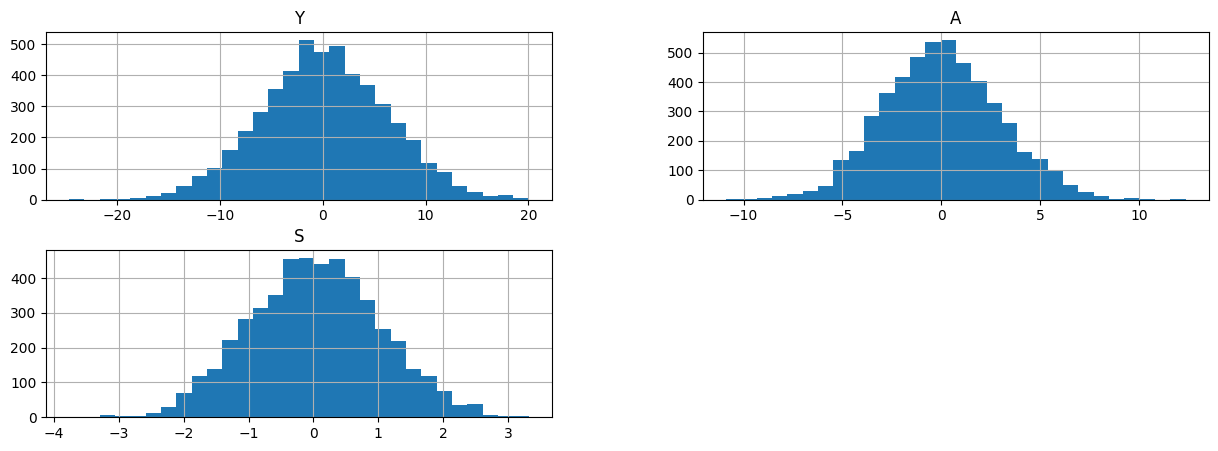

In [27]:
#Qst d)
import numpy as np
# 1. Update Noise (assuming you are generating the data)
n = 5000
S = np.random.normal(0, 1, n)
A = 0.8 * S + np.random.normal(0, np.sqrt(8), n) # High noise
P = np.random.normal(0, 1, n)
D = 0.7 * A - 0.5 * P + 0.4 * S + np.random.normal(0, np.sqrt(8), n) # High noise
Y = 1.5 * D - 0.3 * P + np.random.normal(0, np.sqrt(8), n) # High noise

df_high_noise = pd.DataFrame({'S': S, 'A': A, 'P': P, 'D': D, 'Y': Y})

# (a) Histograms
df_high_noise[['Y', 'A', 'S']].hist(bins=30, figsize=(15, 5))

# (b) Covariance
print("New Cov(A, Y):", df_high_noise['A'].cov(df_high_noise['Y']))

# (c) Regressions
# Model 1: Y ~ A
m1 = sm.OLS(df_high_noise['Y'], sm.add_constant(df_high_noise['A'])).fit()
# Model 2: Y ~ A + S
m2 = sm.OLS(df_high_noise['Y'], sm.add_constant(df_high_noise[['A', 'S']])).fit()

print("Simple Coeff A:", m1.params['A'])
print("Multiple Coeff A:", m2.params['A'])

With high noise, the data becomes less precise. While the causal structure 

($A \to D \to Y$) remains the same, the estimates are "washed out" by the randomness. The bias is still there, but it is buried under a much larger layer of uncertainty.